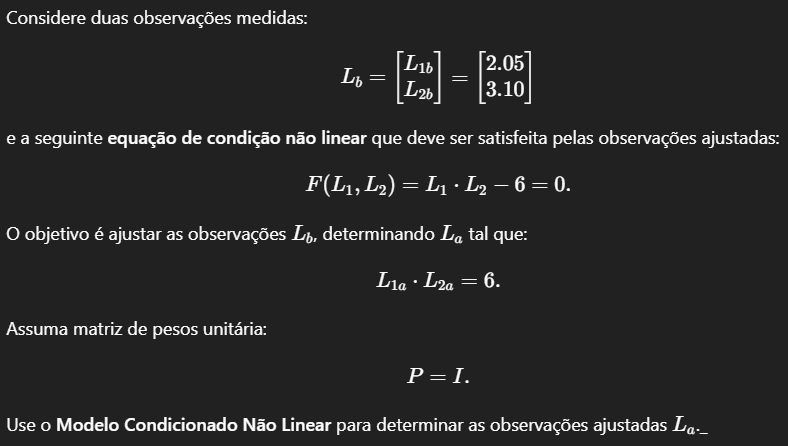

In [1]:
import numpy as np

# -----------------------------
# Dados observados (Lb)
# -----------------------------
Lb = np.array([2.05, 3.10])     # L1, L2 medidos
P = np.diag([1.0, 1.0])
Pinv = np.linalg.inv(P)

# -----------------------------
# F(L) = 0  (modelo condicionado puro)
# -----------------------------
def F(L):
    L1, L2 = L
    return np.array([L1 * L2 - 6.0])

def B_matrix(L):
    L1, L2 = L
    # B = [dF/dL1, dF/dL2] = [L2, L1]
    return np.array([[L2, L1]])

# -----------------------------
# Iteração conforme slide
# -----------------------------
La = Lb.copy()     # La^(0) = Lb
tol = 1e-12

for i in range(10):

    B = B_matrix(La)

    if i == 0:
        # 1ª iteração: W = F(Lb)
        W = F(La)
    else:
        # iterações seguintes: W_i = F(La^(i-1)) + B_i (Lb - La^(i-1))
        W = F(La) + B @ (Lb - La)

    M = B @ Pinv @ B.T
    K = -np.linalg.solve(M, W)
    V = Pinv @ (B.T @ K)

    La_new = Lb + V.flatten()

    print(f"Iter {i+1}: La = {La_new}, ||V|| = {np.linalg.norm(V):.4e}, produto = {La_new[0]*La_new[1]:.6f}")

    if np.linalg.norm(La_new - La) < tol:
        La = La_new
        break

    La = La_new

print("\nObservações ajustadas (La):", La)
print("Produto L1*L2 =", La[0]*La[1])

Iter 1: La = [1.97032579 3.04731222], ||V|| = 9.5520e-02, produto = 6.004198
Iter 2: La = [1.96881989 3.04751071], ||V|| = 9.6671e-02, produto = 6.000000
Iter 3: La = [1.96880012 3.04754147], ||V|| = 9.6671e-02, produto = 6.000000
Iter 4: La = [1.96879964 3.04754221], ||V|| = 9.6671e-02, produto = 6.000000
Iter 5: La = [1.96879963 3.04754223], ||V|| = 9.6671e-02, produto = 6.000000
Iter 6: La = [1.96879962 3.04754223], ||V|| = 9.6671e-02, produto = 6.000000
Iter 7: La = [1.96879962 3.04754223], ||V|| = 9.6671e-02, produto = 6.000000
Iter 8: La = [1.96879962 3.04754223], ||V|| = 9.6671e-02, produto = 6.000000

Observações ajustadas (La): [1.96879962 3.04754223]
Produto L1*L2 = 5.999999999999999
